# Global Digital Advertising Performance Analysis

# 04 - Feature Engineering

## Objective

Feature engineering involves creating new variables from existing data to generate additional business insights. These derived metrics help evaluate campaign profitability, efficiency, and overall marketing performance.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_csv("../data/global_ads_performance_dataset.csv")

df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.04,1.26,"2,662.38",159,16.74,"4,803.43",1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.04,1.18,"6,159.60",411,14.99,"64,126.68",10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.06,0.85,"5,092.35",267,19.07,"10,489.07",2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.07,1.32,"7,834.20",296,26.47,"50,505.07",6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.05,1.93,"8,663.77",107,80.97,"3,369.53",0.39


## Creating New Features

## Feature 1

### Profit

Profit represents the amount of money remaining after subtracting advertising spend from generated revenue.

In [3]:
df["profit"] = df["revenue"] - df["ad_spend"]

df[["revenue","ad_spend","profit"]].head()

,revenue,ad_spend,profit
0,"4,803.43","2,662.38","2,141.05"
1,"64,126.68","6,159.60","57,967.08"
2,"10,489.07","5,092.35","5,396.72"
3,"50,505.07","7,834.20","42,670.87"
4,"3,369.53","8,663.77","-5,294.24"


## Feature 2

### Conversion Rate

Conversion Rate measures the proportion of clicks that resulted in conversions.

In [4]:
df["conversion_rate"] = df["conversions"] / df["clicks"]

df[["clicks","conversions","conversion_rate"]].head()

,clicks,conversions,conversion_rate
0,2113,159,0.08
1,5220,411,0.08
2,5991,267,0.04
3,5935,296,0.05
4,4489,107,0.02


## Feature 3

### CPM (Cost per 1,000 Impressions)

CPM measures the advertising cost required to generate one thousand impressions.

In [5]:
df["CPM"] = (df["ad_spend"] / df["impressions"]) * 1000

df[["ad_spend","impressions","CPM"]].head()

,ad_spend,impressions,CPM
0,"2,662.38",59886,44.46
1,"6,159.60",135608,45.42
2,"5,092.35",92313,55.16
3,"7,834.20",83953,93.32
4,"8,663.77",91807,94.37


## Feature 4

### Profit Margin

Profit Margin measures the proportion of revenue retained as profit after advertising expenses.

In [6]:
df["profit_margin"] = df["profit"] / df["revenue"]

df[["profit","revenue","profit_margin"]].head()

,profit,revenue,profit_margin
0,"2,141.05","4,803.43",0.45
1,"57,967.08","64,126.68",0.90
2,"5,396.72","10,489.07",0.51
3,"42,670.87","50,505.07",0.84
4,"-5,294.24","3,369.53",-1.57


In [7]:
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS,profit,conversion_rate,CPM,profit_margin
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.04,1.26,"2,662.38",159,16.74,"4,803.43",1.80,"2,141.05",0.08,44.46,0.45
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.04,1.18,"6,159.60",411,14.99,"64,126.68",10.41,"57,967.08",0.08,45.42,0.90
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.06,0.85,"5,092.35",267,19.07,"10,489.07",2.06,"5,396.72",0.04,55.16,0.51
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.07,1.32,"7,834.20",296,26.47,"50,505.07",6.45,"42,670.87",0.05,93.32,0.84
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.05,1.93,"8,663.77",107,80.97,"3,369.53",0.39,"-5,294.24",0.02,94.37,-1.57


# Business Analysis of Engineered Features

## Business Question 1

### Which advertising platform generates the highest total profit?

In [8]:
platform_profit = (
    df.groupby("platform")["profit"]
    .sum()
    .sort_values(ascending=False)
)

platform_profit

platform
TikTok Ads   17,570,121.56
Google Ads   15,684,476.04
Meta Ads      9,819,984.12
Name: profit, dtype: float64

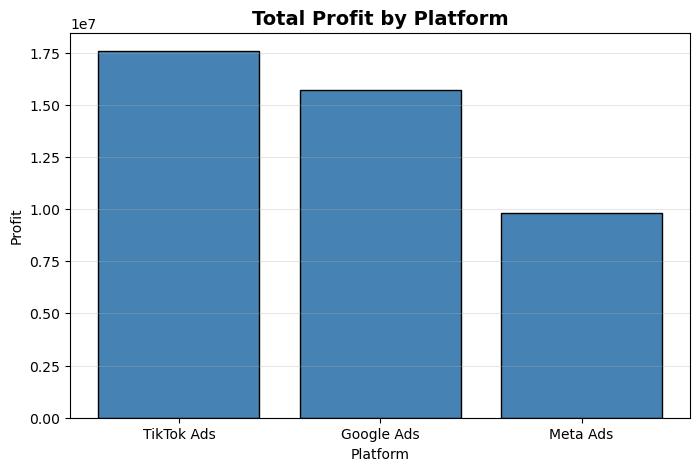

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    platform_profit.index,
    platform_profit.values,
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Total Profit by Platform",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Platform")
plt.ylabel("Profit")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Business Insight

TikTok Ads generated the highest total profit, outperforming both Google Ads and Meta Ads. This suggests that campaigns executed on TikTok produced the strongest financial returns within the analyzed period.

From a business perspective, decision-makers may consider allocating additional budget toward TikTok campaigns while investigating why Meta Ads generated comparatively lower profitability.

## Business Question 2

### Which campaign type has the highest aggregate profit margin?

In [10]:
campaign_margin = (
    df.groupby("campaign_type")
    .agg(
        total_profit=("profit", "sum"),
        total_revenue=("revenue", "sum")
    )
    .assign(
        profit_margin=lambda data: (
            data["total_profit"] /
            data["total_revenue"]
        )
    )["profit_margin"]
    .sort_values(ascending=False)
)

campaign_margin

campaign_type
Search     0.81
Display    0.79
Video      0.79
Shopping   0.78
Name: profit_margin, dtype: float64

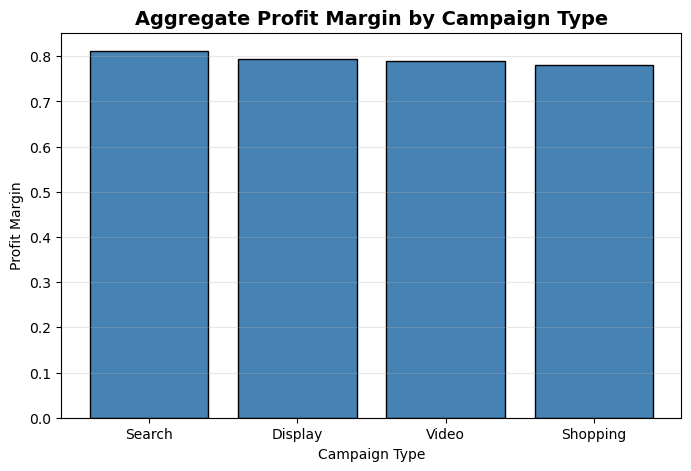

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    campaign_margin.index,
    campaign_margin.values,
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Aggregate Profit Margin by Campaign Type",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Campaign Type")
plt.ylabel("Profit Margin")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Business Insight

Search and Display campaigns achieved the highest average profit margins, indicating that these campaign types retain a larger proportion of revenue after advertising costs.

Shopping campaigns recorded the lowest profit margin, suggesting opportunities for optimization through improved targeting, creative strategies, or budget allocation.

## Business Question 3

### Which country has the highest average conversion rate?

In [17]:
country_conversion = (
    df.groupby("country")
    .agg(
        total_conversions=("conversions", "sum"),
        total_clicks=("clicks", "sum")
    )
    .assign(
        conversion_rate=lambda data: (
            data["total_conversions"] /
            data["total_clicks"]
        )
    )["conversion_rate"]
    .sort_values(ascending=False)
)

country_conversion

country
Australia   0.05
UK          0.05
India       0.05
UAE         0.05
USA         0.05
Germany     0.05
Canada      0.04
Name: conversion_rate, dtype: float64

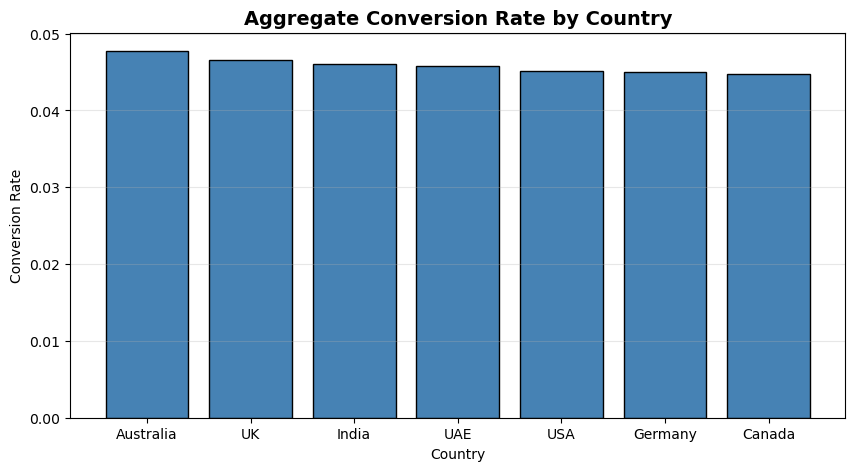

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    country_conversion.index,
    country_conversion.values,
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Aggregate Conversion Rate by Country",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Country")
plt.ylabel("Conversion Rate")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Business Insight

Aggregate conversion rates were relatively consistent across countries. Australia recorded the highest rate at approximately 4.77%, followed by the UK and India. Because the differences are modest, market decisions should also consider revenue, profit and ROAS.

## Business Question 4

### Which industry has the lowest average CPM?

In [18]:
industry_cpm = (
    df.groupby("industry")
    .agg(
        total_ad_spend=("ad_spend", "sum"),
        total_impressions=("impressions", "sum")
    )
    .assign(
        CPM=lambda data: (
            data["total_ad_spend"] /
            data["total_impressions"]
        ) * 1000
    )["CPM"]
    .sort_values()
)

industry_cpm

industry
E-commerce   56.92
EdTech       57.66
Fintech      61.45
Healthcare   61.68
SaaS         61.99
Name: CPM, dtype: float64

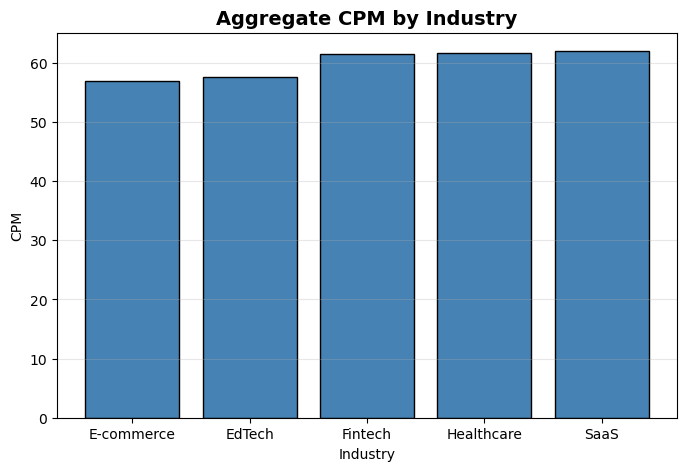

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    industry_cpm.index,
    industry_cpm.values,
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Aggregate CPM by Industry",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Industry")
plt.ylabel("CPM")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Business Insight

E-commerce achieved the lowest aggregate CPM at approximately 56.92, indicating the lowest cost per thousand impressions. SaaS recorded the highest aggregate CPM at approximately 61.99.